In [16]:
import sys
import os
from pathlib import Path
from importlib.metadata import version
from qiskit.visualization import circuit_drawer
import qiskit
import networkx as nx

from qiskit import QuantumCircuit, transpile, qasm2
from qiskit.transpiler import CouplingMap


print("Python version :", sys.version)
print("Qiskit version :", version("qiskit"))
print("NetworkX version:", nx.__version__)
print("Working directory:", os.getcwd())

print("\nImports: OK")

Python version : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Qiskit version : 0.45.3
NetworkX version: 3.6.1
Working directory: C:\Users\ASUS\Documents\Quantum computing\Qiskit\CaQR-main\CaQR-main

Imports: OK


In [4]:
# Simple Qiskit smoke test

qc_test = QuantumCircuit(2, 2)

qc_test.h(0)
qc_test.cx(0, 1)
qc_test.measure([0, 1], [0, 1])

print("Original circuit:")
print(qc_test)

print("Qubits:", qc_test.num_qubits)
print("Depth :", qc_test.depth())

Original circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 
Qubits: 2
Depth : 3


In [5]:
# Save as OpenQASM 2
qasm2.dump(qc_test, "test_circuit.qasm")

print("QASM export: OK")


# Load it again
qc_loaded = qasm2.load("test_circuit.qasm")

print("QASM import: OK")
print(qc_loaded)

QASM export: OK
QASM import: OK
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [11]:
coupling_map = CouplingMap(
    couplinglist=[
        [0, 1],
        [1, 0]
    ]
)

qc_transpiled = transpile(
    qc_loaded,
    coupling_map=coupling_map,
    optimization_level=1,
    routing_method="sabre",
    seed_transpiler=0
)

print("Transpile: OK")
print(qc_transpiled)

Transpile: OK
         ┌───┐     ┌─┐   
q_0 -> 0 ┤ H ├──■──┤M├───
         └───┘┌─┴─┐└╥┘┌─┐
q_1 -> 1 ─────┤ X ├─╫─┤M├
              └───┘ ║ └╥┘
    c: 2/═══════════╩══╩═
                    0  1 


In [8]:
import subprocess
import sys

result = subprocess.run(
    [
        sys.executable,
        "main.py",
        "-b",
        "benchmarks/bv_n10.qasm",
        "-v",
        "0"
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)

print("\n----- STDOUT -----")
print(result.stdout)

print("\n----- STDERR -----")
print(result.stderr)

RETURN CODE: 0

----- STDOUT -----
We reuse 8 qubits, and now a total of 2 logical qubits are used.


----- STDERR -----



In [9]:
output_files = [
    "output/bv_n10_reuse.qasm",
    "output/bv_n10_reuse_chain.txt",
    "output/bv_n10_reuse_map.txt"
]

for file in output_files:
    exists = Path(file).exists()
    print(f"{file:40} {'✅' if exists else '❌'}")

output/bv_n10_reuse.qasm                 ✅
output/bv_n10_reuse_chain.txt            ✅
output/bv_n10_reuse_map.txt              ✅


In [10]:
reuse_qc = qasm2.load("output/bv_n10_reuse.qasm")

print("CaQR output loaded into Qiskit ✅")

print("Number of qubits:", reuse_qc.num_qubits)
print("Depth:", reuse_qc.depth())
print("Gate counts:", reuse_qc.count_ops())

CaQR output loaded into Qiskit ✅
Number of qubits: 10
Depth: 45
Gate counts: OrderedDict({'h': 20, 'cx': 9, 'measure': 9, 'reset': 8, 'x': 1})


In [9]:
validation = subprocess.run(
    [
        sys.executable,
        "validate.py",
        "bv_n10"
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", validation.returncode)

print("\n----- STDOUT -----")
print(validation.stdout)

print("\n----- STDERR -----")
print(validation.stderr)

RETURN CODE: 0

----- STDOUT -----
Validation passed


----- STDERR -----



In [10]:
from pathlib import Path

print("========== REUSE CHAIN ==========")
print(
    Path("output/bv_n10_reuse_chain.txt")
    .read_text()
)

print("\n========== REUSE MAP ==========")
print(
    Path("output/bv_n10_reuse_map.txt")
    .read_text()
)

========== REUSE CHAIN ==========
0  -> 1  -> 2  -> 3  -> 4  -> 5  -> 6  -> 7  -> 8 


========== REUSE MAP ==========
0 : {   1 ,  2 ,  3 ,  4 ,  5 ,  6 ,  7 ,  8 }



In [11]:
print("========== ORIGINAL QASM ==========")

with open("benchmarks/bv_n10.qasm", "r") as f:
    original_qasm = f.read()

print(original_qasm)


print("\n========== CaQR OUTPUT QASM ==========")

with open("output/bv_n10_reuse.qasm", "r") as f:
    reuse_qasm = f.read()

print(reuse_qasm)

========== ORIGINAL QASM ==========
OPENQASM 2.0;
include "qelib1.inc";
qreg q[10];
creg c[9];
h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
h q[6];
h q[7];
h q[8];
x q[9];
h q[9];

cx q[0],q[9];
cx q[1],q[9];
cx q[2],q[9];
cx q[3],q[9];
cx q[4],q[9];
cx q[5],q[9];
cx q[6],q[9];
cx q[7],q[9];
cx q[8],q[9];


h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
h q[6];
h q[7];
h q[8];
h q[9];

measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];
measure q[4] -> c[4];
measure q[5] -> c[5];
measure q[6] -> c[6];
measure q[7] -> c[7];
measure q[8] -> c[8];



========== CaQR OUTPUT QASM ==========
OPENQASM 2.0;
include "qelib1.inc";
qreg q[10];
creg c[9];
h q[0];
x q[9];
h q[9];
cx q[0],q[9];
h q[0];
measure q[0] -> c[0];
reset q[0];
h q[0];
cx q[0],q[9];
h q[0];
measure q[0] -> c[1];
reset q[0];
h q[0];
cx q[0],q[9];
h q[0];
measure q[0] -> c[2];
reset q[0];
h q[0];
cx q[0],q[9];
h q[0];
measure q[0] -> c[3];
reset q[0];
h q[0];
cx q[0],q[9];
h q[0];
measur

========== ORIGINAL QASM ==========


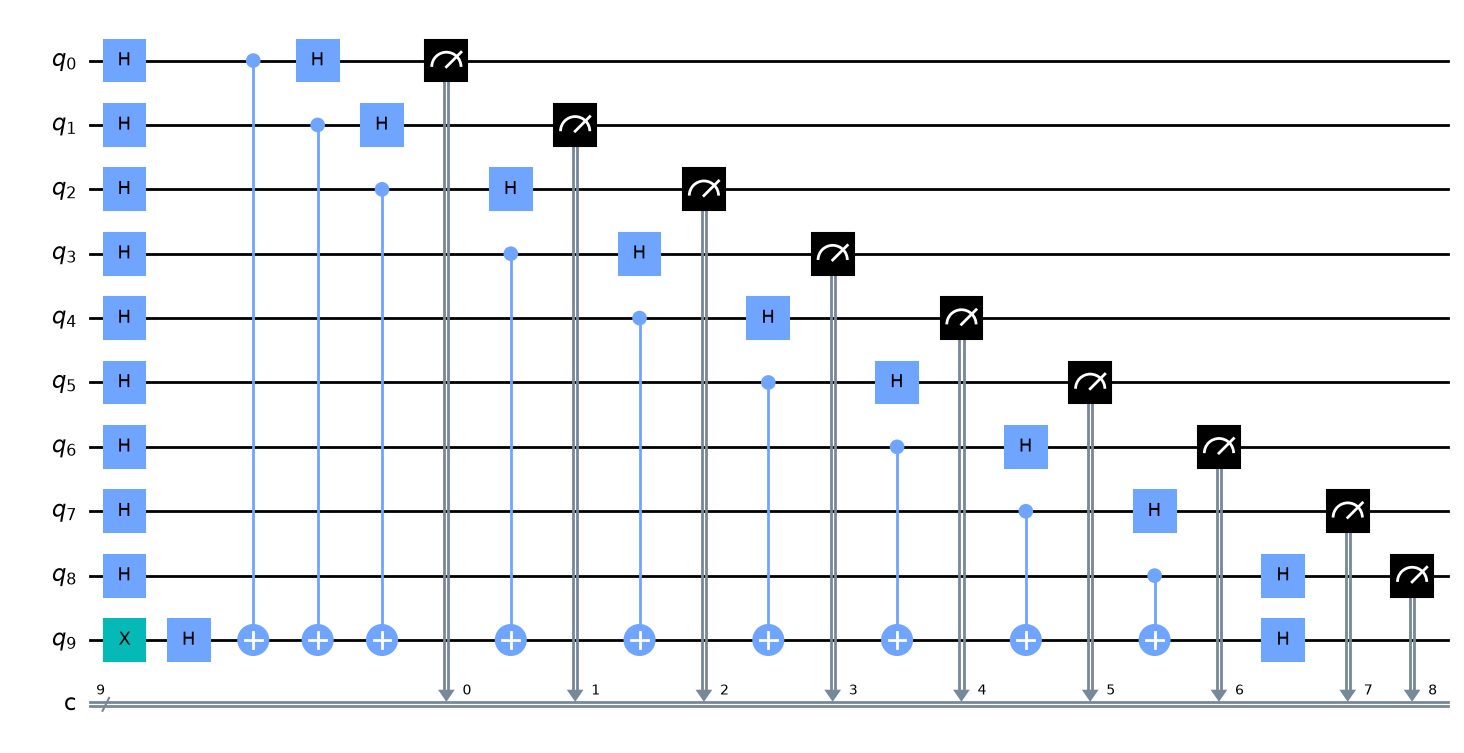

In [22]:
print("========== ORIGINAL QASM ==========")

original_qasm = qasm2.load("benchmarks/bv_n10.qasm")

original_qasm.draw(output="mpl")




========== CaQR OUTPUT QASM ==========


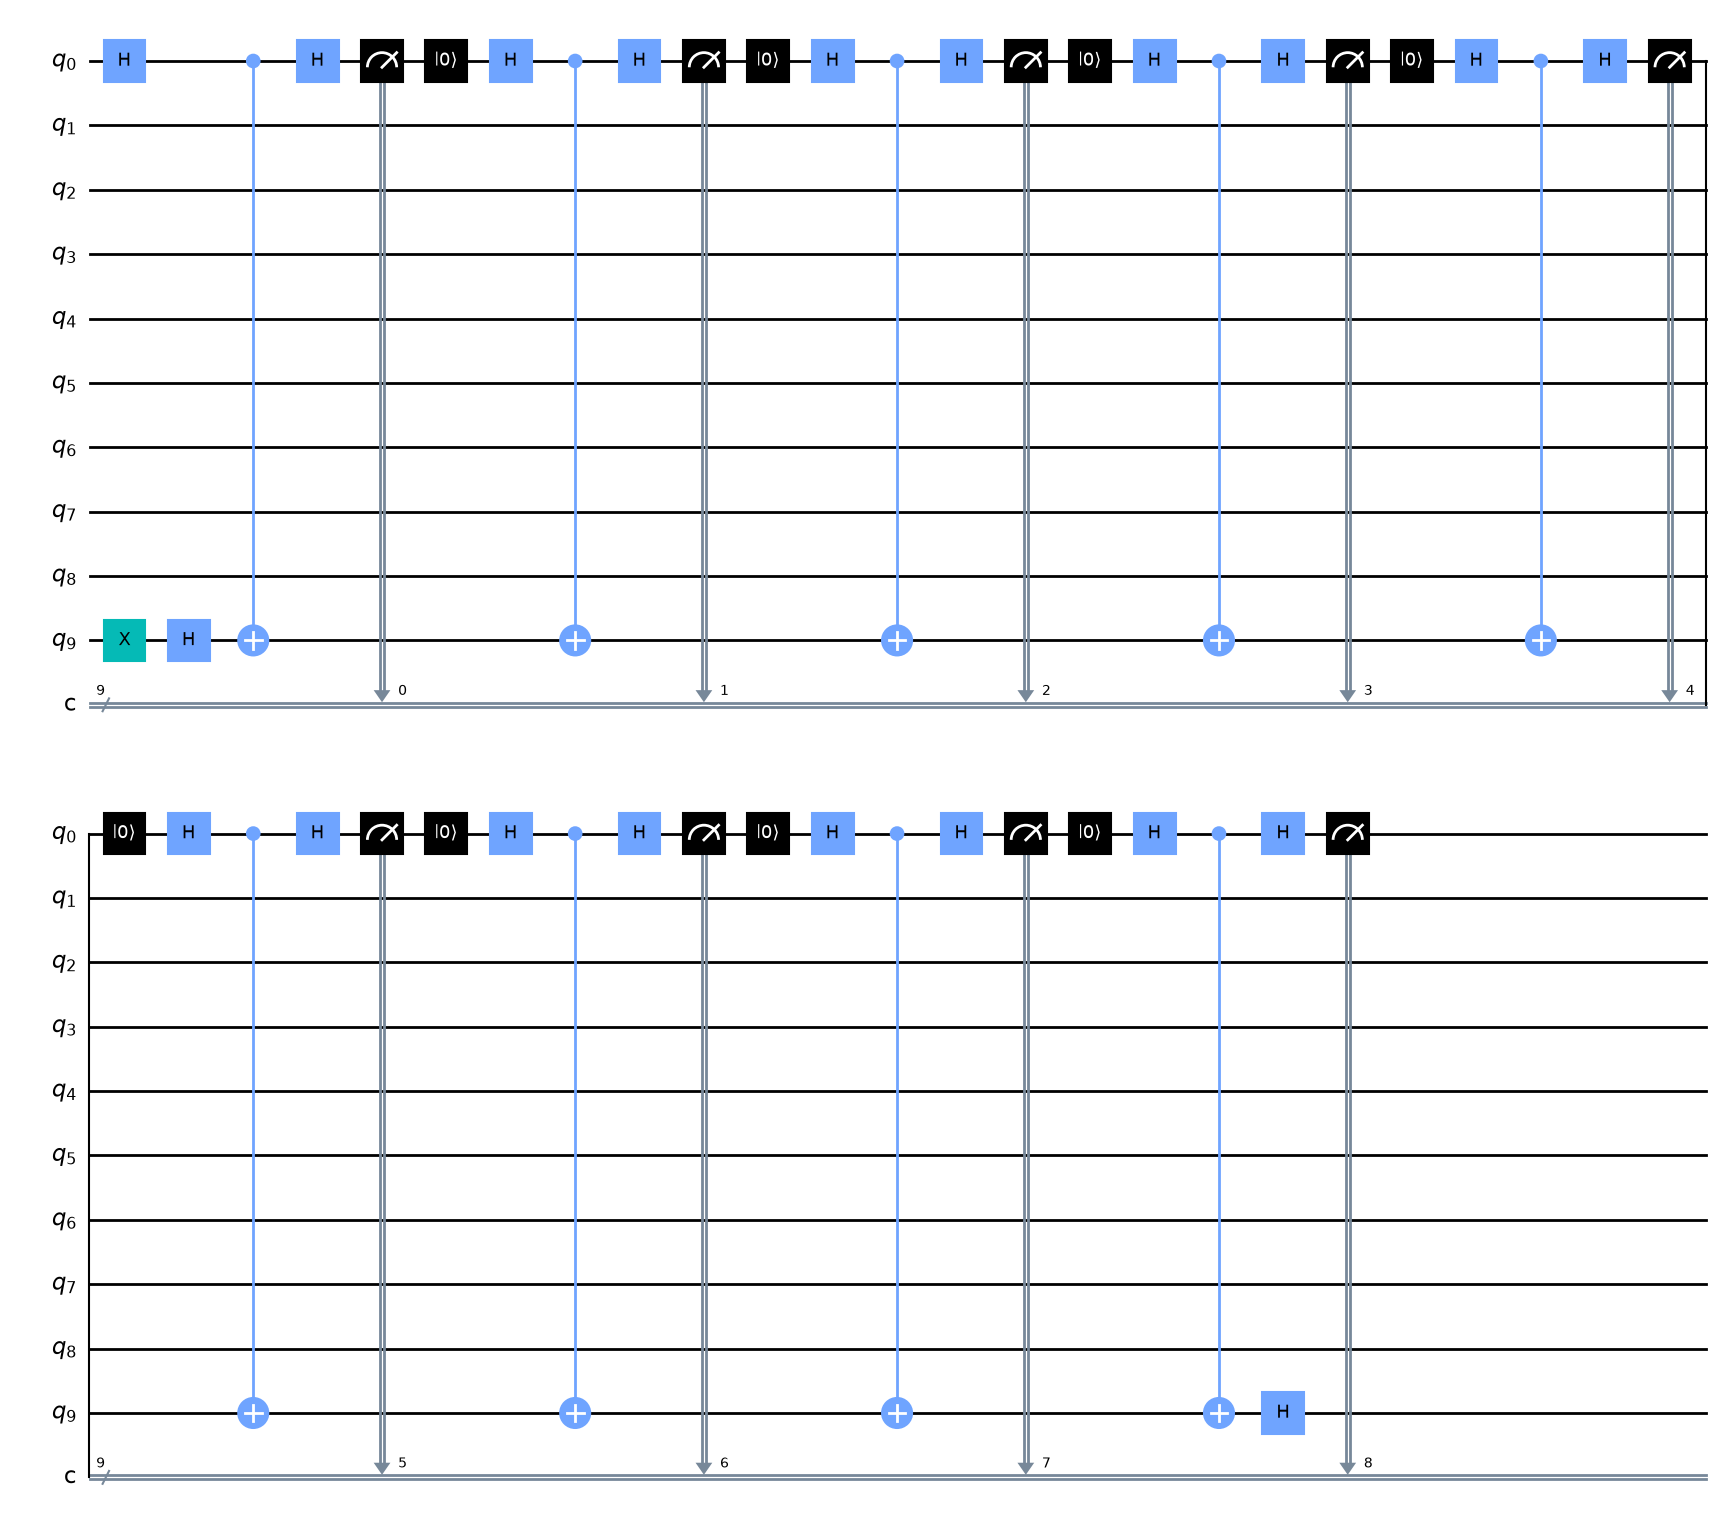

In [23]:

print("\n========== CaQR OUTPUT QASM ==========")

reuse_qasm = qasm2.load("output/bv_n10_reuse.qasm")

reuse_qasm.draw(output="mpl")

In [24]:
def get_active_qubits(circuit):
    active = set()

    for instruction in circuit.data:
        for qubit in instruction.qubits:
            active.add(circuit.find_bit(qubit).index)

    return sorted(active)


active_original = get_active_qubits(
    qasm2.load("benchmarks/bv_n10.qasm")
)

active_reuse = get_active_qubits(
    qasm2.load("output/bv_n10_reuse.qasm")
)


print("Original active qubits:", active_original)
print("Original active qubit count:", len(active_original))

print()

print("After CaQR active qubits:", active_reuse)
print("After CaQR active qubit count:", len(active_reuse))

Original active qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Original active qubit count: 10

After CaQR active qubits: [0, 9]
After CaQR active qubit count: 2
